In [1]:
import os, re, unicodedata, hashlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

plt.rcParams['font.family'] = 'Arial'

import warnings
warnings.filterwarnings("ignore")

In [2]:
cd C:\Users\tr432\Downloads

C:\Users\tr432\Downloads


In [25]:
# ===============================
# USER INPUT (Edit)
# ===============================
FILES = {
    "0w": "filter_GutLungAxis_Week0/rel_gg2_genus_table.tsv",
    "1w": "filter_GutLungAxis_Week1/rel_gg2_genus_table.tsv",
    "2w": "filter_GutLungAxis_Week2/rel_gg2_genus_table.tsv",
}
#tax = "d__Bacteria;p__Pseudomonadota;c__Gammaproteobacteria;o__Enterobacterales_737866;f__Enterobacteriaceae_A_725029;g__Escherichia"  # Edit: '#OTU ID' 열에서 "정확히 일치"하는 문자열
tax = "d__Bacteria;p__Pseudomonadota;c__Gammaproteobacteria;o__Enterobacterales_737866;f__Enterobacteriaceae_A_732334;g__Proteus"  # Edit: '#OTU ID' 열에서 "정확히 일치"하는 문자열

# q-value는 직접 입력 (각 week별)
QVAL = {
#    "0w": 0.969559160205498,     #Edit: Escherichia
    "0w": "N/A",                 #Edit: Proteus

#    "1w": 0.00223092775681831,   # Edit: Escherichia
    "1w": 0.00223092775681831,   # Edit: Proteus

#    "2w": 0.0060131262574342     #Edit: Escherichia
    "2w": 0.0427648340744448     # Edit: Proteus
}

# (선택) y축 log10 변환이 필요하면 True (상대풍부도면 보통 False 권장)
APPLY_LOG10 = False
PSEUDO = 1  # log10용

# 그룹 판별 규칙(필요시 수정)
def infer_group(sample_name: str) -> str | None:
    s = str(sample_name).strip()
    if s.startswith("C"): return "Control"
    if s.startswith("V"): return "VNAM"
    return None

WEEKS = ["0w", "1w", "2w"]
GROUP_ORDER = ["Control", "VNAM"]

In [26]:
# ===============================
# Helpers
# ===============================
def q_to_stars(q):
    # q가 문자열("N/A" 등)이면 ns로 간주
    try:
        qf = float(q)
    except (TypeError, ValueError):
        return "ns"
    if np.isnan(qf):
        return "ns"
    if qf < 0.001: return "***"
    if qf < 0.01:  return "**"
    if qf < 0.05:  return "*"
    return "ns"

def format_q(q):
    # 표기용: 숫자면 scientific, 아니면 문자열 그대로
    try:
        qf = float(q)
        if np.isnan(qf):
            return "N/A"
        return f"{qf:.2e}"
    except (TypeError, ValueError):
        return str(q)


def add_bracket(ax, x1, x2, y, h, text):
    ax.plot([x1, x1, x2, x2], [y, y+0.5*h, y+0.5*h, y], lw=1, c="k")
    ax.text((x1+x2)/2, y+0.5*h, text, ha="center", va="bottom", fontsize=20, fontweight='bold')

def infer_subject_id(sample_name: str, wk: str) -> str:
    s = str(sample_name).strip()
    # 예: C01_0w / C01-0w / C01.0w 같은 suffix 제거
    s = re.sub(rf'([_\-\.]?)\b{re.escape(wk)}\b$', "", s)
    s = re.sub(r'[_\-\.\s]+$', "", s)
    return s

In [27]:
# ===============================
# 1) Load -> long format
# ===============================
rows = []
for wk in WEEKS:
    dfw = pd.read_csv(FILES[wk], sep="\t", skiprows=1)
    if "#OTU ID" not in dfw.columns:
        raise ValueError(f"[{wk}] '#OTU ID' 컬럼이 없습니다. 현재 컬럼: {list(dfw.columns)[:10]} ...")

    # ✅ exact match only
    hit = dfw[dfw["#OTU ID"].astype(str).str.strip() == str(tax).strip()]
    if hit.shape[0] != 1:
        if hit.shape[0] == 0:
            # 보조(대소문자만 다른 경우 1개면 허용)
            hit2 = dfw[dfw["#OTU ID"].astype(str).str.strip().str.casefold()
                      == str(tax).strip().casefold()]
            if hit2.shape[0] == 1:
                hit = hit2
            else:
                raise ValueError(f"[{wk}] tax='{tax}' 정확히 일치하는 행이 없습니다. (현재 파일: {FILES[wk]})")
        else:
            raise ValueError(f"[{wk}] tax='{tax}' 정확히 일치하는 행이 {hit.shape[0]}개입니다. 유일해야 합니다.")

    row = hit.iloc[0]

    # sample columns = '#OTU ID' 제외한 나머지
    for col in dfw.columns:
        if col == "#OTU ID":
            continue
        g = infer_group(col)
        if g is None:
            continue
        val = pd.to_numeric(row[col], errors="coerce")
        if pd.isna(val):
            continue
        subj = infer_subject_id(col, wk)
        rows.append({"Week": wk, "Group": g, "Sample": col, "Subject": subj, "Value": float(val)})

dat = pd.DataFrame(rows)
if dat.empty:
    raise ValueError("선택된 tax에 대해 유효한 값이 없습니다(모두 NA/비어있음).")

dat["Value"] = dat["Value"].astype(float) * 100

if APPLY_LOG10:
    dat["Value"] = np.log10(dat["Value"].to_numpy(dtype=float) + PSEUDO)
    YLABEL = "Log10 (Value)"
else:
    YLABEL = "Value"

dat["Group6"] = dat["Week"].astype(str) + "_" + dat["Group"].astype(str)

In [28]:
# dat 컬럼 필요: ["sample_id"(또는 #SampleID), "Group", "Week", "Value"]
# Week 값 예: "0w","1w","2w" / Group 값 예: "Control","VNAM"

# 0) SubjectID(개체ID) 만들기: C01-0w -> C01, V01-2w -> V01
SID_COL = "Subject"  # 실제 컬럼명에 맞게 바꾸세요(#SampleID 등)
dat = dat.copy()
dat["SubjectID"] = dat[SID_COL].astype(str).str.replace(r"-\d+w$", "", regex=True)

WEEKS = ["0w","1w","2w"]
GROUP_ORDER = ["Control","VNAM"]

In [29]:
dat_prev = dat.copy()

# abundance > 0 → 1, ==0 → 0
dat_prev["Value"] = (dat_prev["Value"].astype(float) > 0).astype(int)

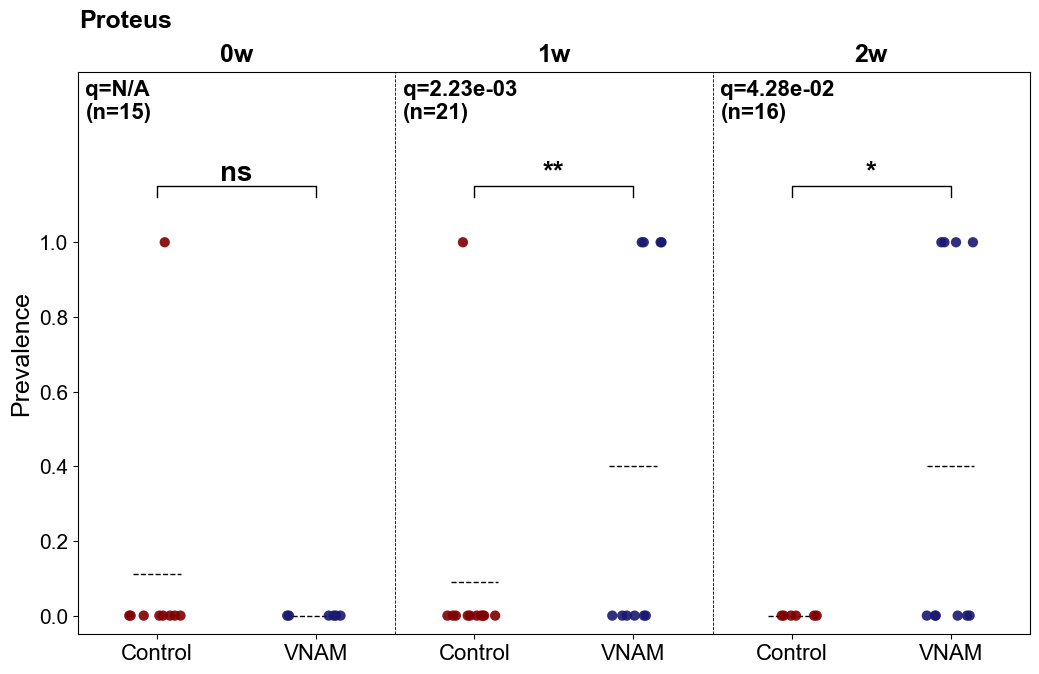

In [30]:
# ===============================
# 2) Plot (single axis, 3 panels separated by vlines)
# ===============================
COLOR = ["maroon", "midnightblue"] * len(WEEKS)

order = []
for wk in WEEKS:
    order += [f"{wk}_{GROUP_ORDER[0]}", f"{wk}_{GROUP_ORDER[1]}"]

centers = {wk: i*2 + 0.5 for i, wk in enumerate(WEEKS)}
vlines  = [1.5 + 2*i for i in range(len(WEEKS)-1)]

# scatter mapping
x_map = {cat: i for i, cat in enumerate(order)}
c_map = {cat: COLOR[i] for i, cat in enumerate(order)}
rng   = np.random.default_rng(0)

fig, ax = plt.subplots(figsize=(10.5, 6.5))

# 1) boxplot
sns.boxplot(
    data=dat_prev, x="Group6", y="Value", order=order,
    showmeans=True, meanline=True, meanprops={'color': 'k', 'lw': 1},
    medianprops={'visible' : False},
    whiskerprops={'visible' : False},
    showcaps=False,
    showbox=False,
    palette=["firebrick", "royalblue"] * len(WEEKS), width=0.3, fliersize=0, ax=ax
)

# 2) outline-only boxes (transparent fill + colored edges)
box_patches = [p for p in ax.patches if isinstance(p, mpatches.PathPatch)]
box_patches = box_patches[:len(order)]

lines = ax.lines
nbox  = len(box_patches)
k     = (len(lines) // nbox) if nbox else 0

for i, p in enumerate(box_patches):
    fc = p.get_facecolor()
    p.set_facecolor((0, 0, 0, 0))
    p.set_edgecolor(fc)
    p.set_linewidth(2)
    if k:
        for ln in lines[i*k:(i+1)*k]:
            ln.set_color(fc)
            ln.set_linewidth(2)

# 3) scatter overlay (jitter)
base_x = dat_prev["Group6"].map(x_map).to_numpy(dtype=float)
jitter = rng.uniform(-0.18, 0.18, size=len(dat_prev))
xj     = base_x + jitter
colors = dat_prev["Group6"].map(c_map).to_list()

ax.scatter(
    xj, dat_prev["Value"].to_numpy(dtype=float),
    s=55, alpha=0.9, c=colors, zorder=3, linewidths=0
)

# week separator vlines
for xv in vlines:
    ax.axvline(xv, ls="--", lw=0.6, c="black", zorder=0)

# x tick labels: Control/VNAM repeat
ax.set_xticks(np.arange(len(order)))
ax.set_xticklabels(GROUP_ORDER * len(WEEKS), rotation=0)

ax.set_yticks(np.arange(0, 1.01, 0.2))   # ✅ 0~1.0까지만 표시
ax.set_yticklabels([f"{t:.1f}" for t in np.arange(0, 1.01, 0.2)])

# week titles
trans = ax.get_xaxis_transform()
for wk in WEEKS:
    ax.text(
        centers[wk], 1.01, wk, transform=trans,
        ha="center", va="bottom", fontsize=18, fontweight="bold", clip_on=False
    )

# brackets + stars + q text (q는 직접 입력)
y_min, y_max = np.nanmin(dat_prev["Value"]), np.nanmax(dat_prev["Value"])
yrng = (y_max - y_min) if np.isfinite(y_max - y_min) and (y_max - y_min) > 0 else 1.0
h = yrng * 0.06
y_bracket_max = y_max

for i, wk in enumerate(WEEKS):
    subw = dat_prev[dat_prev["Week"] == wk]
    if subw.empty:
        continue

    q_raw = QVAL.get(wk, np.nan)  # 숫자/문자열 모두 허용
    n = int(subw.shape[0])  # week 전체 샘플수(=Control+VNAM)

    ymax_w = np.nanmax(subw["Value"])
    y = ymax_w + h*2
    x1, x2 = i*2, i*2 + 1

    add_bracket(ax, x1, x2, y, h, q_to_stars(q_raw))
    y_bracket_max = max(y_bracket_max, y + 0.6*h)

    ax.text(x1-0.45, 0.91, f"q={format_q(q_raw)}\n(n={n})",
        transform=trans, ha="left", va="bottom", fontsize=16, fontweight='bold', clip_on=False)

# y-limits padding
pad_bottom = yrng * 0.05
pad_top    = yrng * 0.3
plt.ylim(y_min - pad_bottom, y_bracket_max + pad_top)

plt.xlim(-0.5, len(order)-0.5)
plt.xlabel('')
plt.xticks(fontsize=16)
plt.yticks(fontsize=15)
plt.ylabel('Prevalence', fontsize=18)

# figure-level title (left)
fig.text(0.08, 1.03, 'Proteus', ha="left", va="top", fontsize=18, fontweight="bold")  #Edit

plt.tight_layout()
plt.savefig('prev_box_Proteus.png', dpi=500, bbox_inches="tight")
plt.show()